In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import random
from sklearn.model_selection import KFold
from PL_Neural_Network import PersistenceLandscapeNN

In [14]:
training_data = pd.read_csv("../Preprocessing/Extracted_Features.csv")
training_data

,image_name,label,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,...,feature_190,feature_191,feature_192,feature_193,feature_194,feature_195,feature_196,feature_197,feature_198,feature_199
0,Tr-glTr_0000.jpg,glioma,2.775558e-17,0.008952,0.017905,0.026857,0.035809,0.044761,0.053714,0.062666,...,0.088057,0.078273,0.068489,0.058705,0.048921,0.039136,0.029352,0.019568,0.009784,0.000000e+00
1,Tr-glTr_0001.jpg,glioma,2.775558e-17,0.008517,0.017033,0.025550,0.034066,0.042583,0.051099,0.059616,...,0.088057,0.078273,0.068489,0.058705,0.048921,0.039136,0.029352,0.019568,0.009784,0.000000e+00
2,Tr-glTr_0002.jpg,glioma,2.775558e-17,0.006734,0.013468,0.020202,0.026936,0.033670,0.040404,0.047138,...,0.082353,0.073203,0.064052,0.054902,0.045752,0.036601,0.027451,0.018301,0.009150,0.000000e+00
3,Tr-glTr_0003.jpg,glioma,2.775558e-17,0.005268,0.010537,0.015805,0.021073,0.026342,0.031610,0.036879,...,0.047415,0.042147,0.036879,0.031610,0.026342,0.021073,0.015805,0.010537,0.005268,2.775558e-17
4,Tr-glTr_0004.jpg,glioma,2.775558e-17,0.006932,0.013864,0.020796,0.027728,0.034660,0.041592,0.048524,...,0.080570,0.071618,0.062666,0.053714,0.044761,0.035809,0.026857,0.017905,0.008952,0.000000e+00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5705,Tr-pi_1452.jpg,pituitary,2.775558e-17,0.006457,0.012913,0.019370,0.025827,0.032284,0.038740,0.045197,...,0.086275,0.076688,0.067102,0.057516,0.047930,0.038344,0.028758,0.019172,0.009586,0.000000e+00
5706,Tr-pi_1453.jpg,pituitary,2.775558e-17,0.008477,0.016954,0.025431,0.033908,0.042385,0.050862,0.059338,...,0.086988,0.077322,0.067657,0.057992,0.048326,0.038661,0.028996,0.019331,0.009665,5.551115e-17
5707,Tr-pi_1454.jpg,pituitary,2.775558e-17,0.006219,0.012438,0.018657,0.024876,0.031095,0.037314,0.043533,...,0.068806,0.061161,0.053516,0.045870,0.038225,0.030580,0.022935,0.015290,0.007645,0.000000e+00
5708,Tr-pi_1455.jpg,pituitary,2.775558e-17,0.009031,0.018063,0.027094,0.036126,0.045157,0.054189,0.063220,...,0.088414,0.078590,0.068766,0.058942,0.049119,0.039295,0.029471,0.019647,0.009824,5.551115e-17


In [15]:
training_data = training_data.iloc[:, 1:]
training_data

,label,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,...,feature_190,feature_191,feature_192,feature_193,feature_194,feature_195,feature_196,feature_197,feature_198,feature_199
0,glioma,2.775558e-17,0.008952,0.017905,0.026857,0.035809,0.044761,0.053714,0.062666,0.071618,...,0.088057,0.078273,0.068489,0.058705,0.048921,0.039136,0.029352,0.019568,0.009784,0.000000e+00
1,glioma,2.775558e-17,0.008517,0.017033,0.025550,0.034066,0.042583,0.051099,0.059616,0.068132,...,0.088057,0.078273,0.068489,0.058705,0.048921,0.039136,0.029352,0.019568,0.009784,0.000000e+00
2,glioma,2.775558e-17,0.006734,0.013468,0.020202,0.026936,0.033670,0.040404,0.047138,0.053872,...,0.082353,0.073203,0.064052,0.054902,0.045752,0.036601,0.027451,0.018301,0.009150,0.000000e+00
3,glioma,2.775558e-17,0.005268,0.010537,0.015805,0.021073,0.026342,0.031610,0.036879,0.042147,...,0.047415,0.042147,0.036879,0.031610,0.026342,0.021073,0.015805,0.010537,0.005268,2.775558e-17
4,glioma,2.775558e-17,0.006932,0.013864,0.020796,0.027728,0.034660,0.041592,0.048524,0.055457,...,0.080570,0.071618,0.062666,0.053714,0.044761,0.035809,0.026857,0.017905,0.008952,0.000000e+00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5705,pituitary,2.775558e-17,0.006457,0.012913,0.019370,0.025827,0.032284,0.038740,0.045197,0.051654,...,0.086275,0.076688,0.067102,0.057516,0.047930,0.038344,0.028758,0.019172,0.009586,0.000000e+00
5706,pituitary,2.775558e-17,0.008477,0.016954,0.025431,0.033908,0.042385,0.050862,0.059338,0.067815,...,0.086988,0.077322,0.067657,0.057992,0.048326,0.038661,0.028996,0.019331,0.009665,5.551115e-17
5707,pituitary,2.775558e-17,0.006219,0.012438,0.018657,0.024876,0.031095,0.037314,0.043533,0.049752,...,0.068806,0.061161,0.053516,0.045870,0.038225,0.030580,0.022935,0.015290,0.007645,0.000000e+00
5708,pituitary,2.775558e-17,0.009031,0.018063,0.027094,0.036126,0.045157,0.054189,0.063220,0.072252,...,0.088414,0.078590,0.068766,0.058942,0.049119,0.039295,0.029471,0.019647,0.009824,5.551115e-17


In [16]:
training_data = training_data.to_numpy()
training_inputs = training_data[:, 1:201]
training_labels = training_data[:, 0]

In [17]:
training_inputs = training_inputs.astype(float)

In [18]:
training_inputs

array([[2.77555756e-17, 8.95226778e-03, 1.79045356e-02, ...,
        1.95682313e-02, 9.78411567e-03, 0.00000000e+00],
       [2.77555756e-17, 8.51653793e-03, 1.70330759e-02, ...,
        1.95682313e-02, 9.78411567e-03, 0.00000000e+00],
       [2.77555756e-17, 6.73400673e-03, 1.34680135e-02, ...,
        1.83006536e-02, 9.15032680e-03, 0.00000000e+00],
       ...,
       [2.77555756e-17, 6.21905328e-03, 1.24381066e-02, ...,
        1.52901565e-02, 7.64507823e-03, 0.00000000e+00],
       [2.77555756e-17, 9.03149138e-03, 1.80629828e-02, ...,
        1.96474549e-02, 9.82372747e-03, 5.55111512e-17],
       [2.77555756e-17, 8.75420875e-03, 1.75084175e-02, ...,
        1.94890077e-02, 9.74450386e-03, 0.00000000e+00]],
      shape=(5710, 200))

In [19]:
def Standardize(data, index):
    arr = data[index]
    mean = np.mean(arr)
    std = np.std(arr)
    mean_array = np.full(len(arr), mean)
    result = (arr - mean_array) * (1 / std)
    data[index] = result

for i in range(len(training_inputs)):
    Standardize(training_inputs, i)

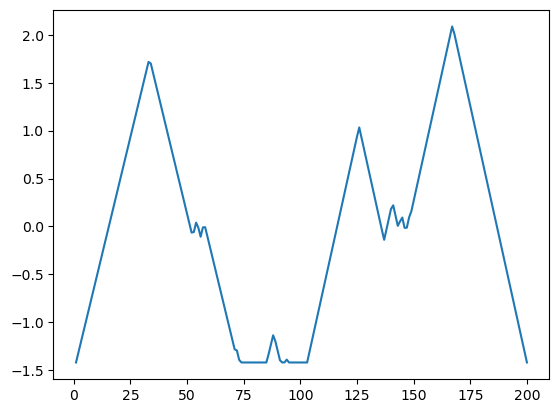

In [20]:
nums = list(range(1, 201))

plt.plot(nums, training_inputs[0])

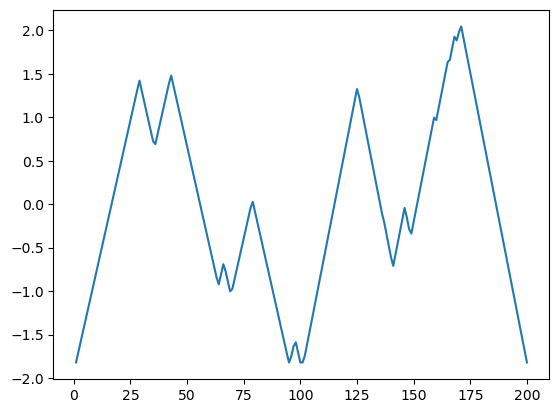

In [21]:
plt.plot(nums, training_inputs[1])

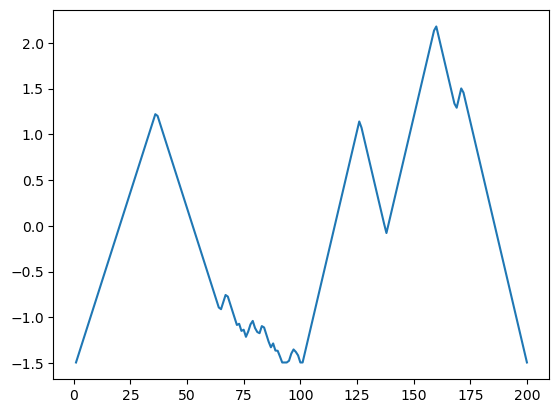

In [22]:
plt.plot(nums, training_inputs[2])

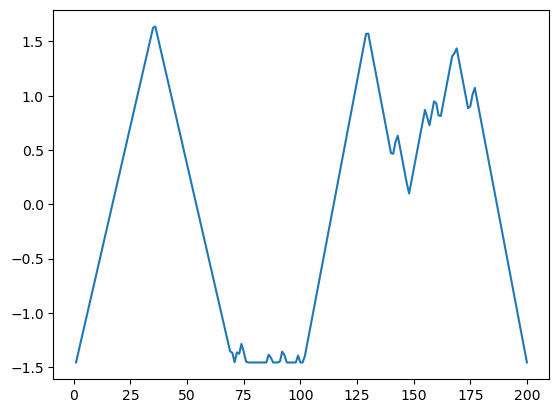

In [23]:
plt.plot(nums, training_inputs[500])